In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\Downloads\bank_customers.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
total_churned =df['churn'].sum()
churn_rate = round(df['churn'].sum()/len(df)*100,2)
print("Total Churned Customers:",total_churned)
print("Churn Rate (%):",churn_rate)

Total Churned Customers: 204
Churn Rate (%): 20.4


In [3]:
# Example: Gender wise
gender_churn = df.groupby('gender').agg(
    total_customers=('customer_id','count'),
    churned=('churn','sum')
)
gender_churn['churn_rate'] = round(gender_churn['churned']/gender_churn['total_customers']*100,2)
print(gender_churn)

# Example: Country wise
country_churn = df.groupby('country').agg(
    total_customers=('customer_id','count'),
    churned=('churn','sum')
)
country_churn['churn_rate'] = round(country_churn['churned']/country_churn['total_customers']*100,2)
print(country_churn)

        total_customers  churned  churn_rate
gender                                      
Female              467      121       25.91
Male                533       83       15.57
         total_customers  churned  churn_rate
country                                      
France               482       77       15.98
Germany              259       75       28.96
Spain                259       52       20.08


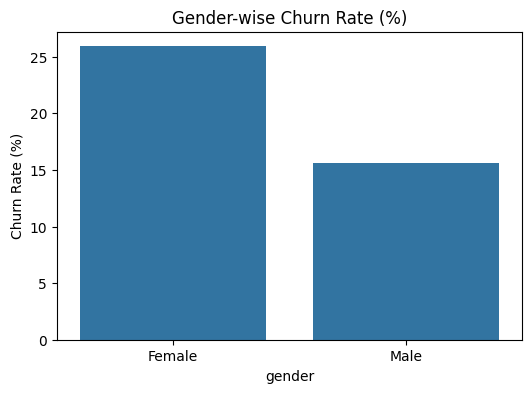

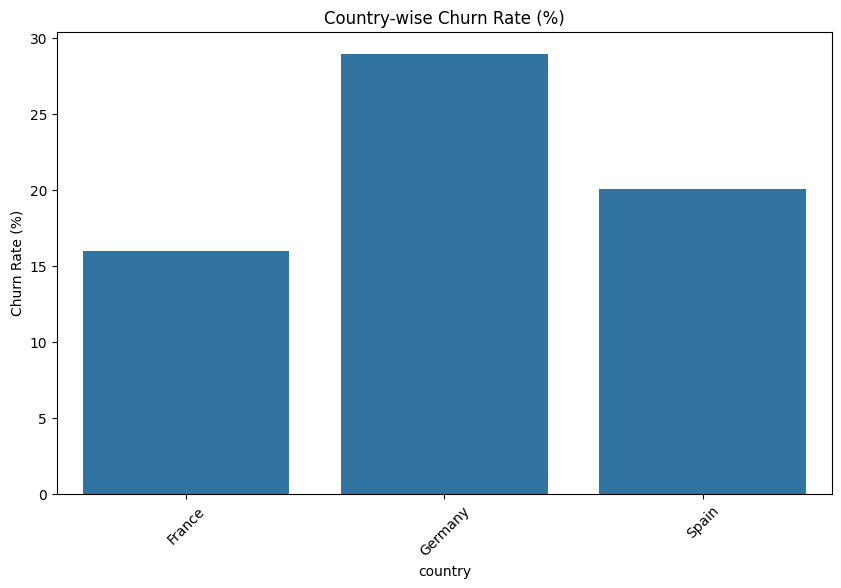

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gender wise churn rate
plt.figure(figsize=(6,4))
sns.barplot(x=gender_churn.index, y=gender_churn['churn_rate'])
plt.title("Gender-wise Churn Rate (%)")
plt.ylabel("Churn Rate (%)")
plt.show()

# Country wise churn rate
plt.figure(figsize=(10,6))
sns.barplot(x=country_churn.index, y=country_churn['churn_rate'])
plt.xticks(rotation=45)
plt.title("Country-wise Churn Rate (%)")
plt.ylabel("Churn Rate (%)")
plt.show()

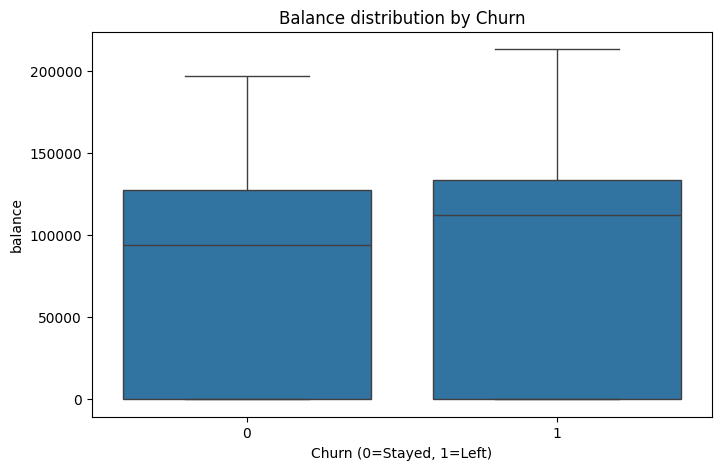

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='balance', data=df)
plt.title("Balance distribution by Churn")
plt.xlabel("Churn (0=Stayed, 1=Left)")
plt.show()

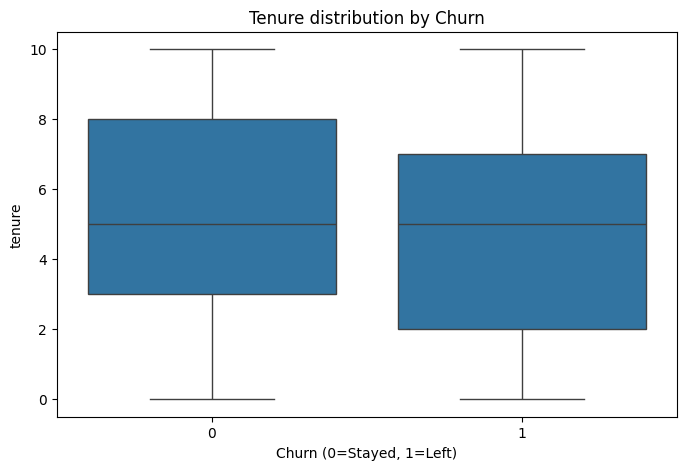

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tenure distribution by Churn")
plt.xlabel("Churn (0=Stayed, 1=Left)")
plt.show()

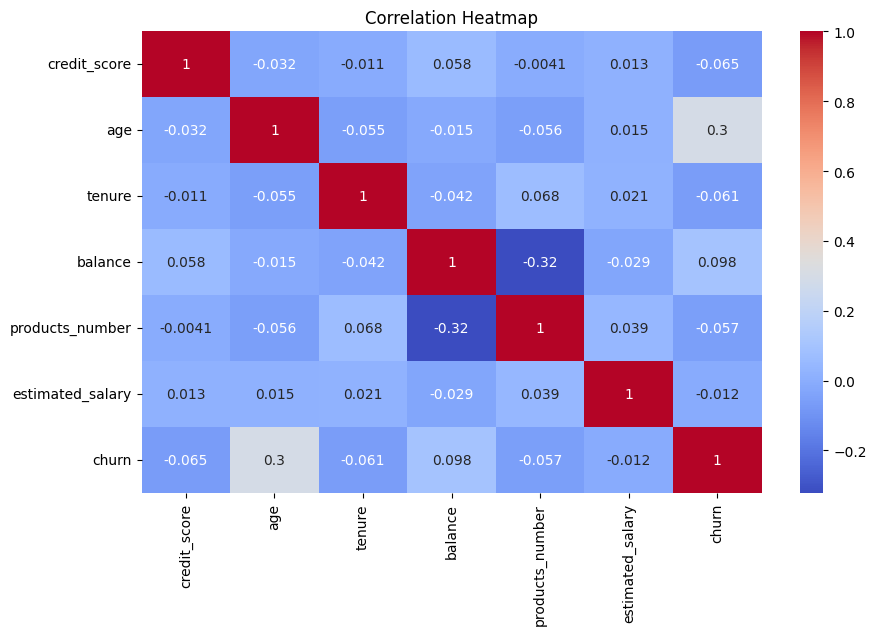

In [7]:
numeric_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary','churn']
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

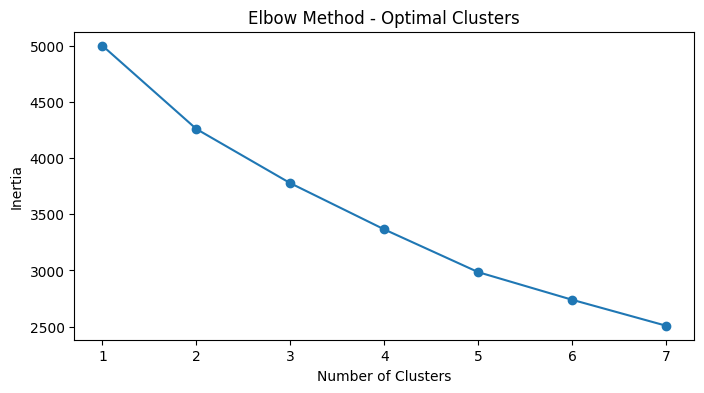

         total_customers  avg_balance  avg_age  churn_rate
cluster                                                   
0                    316     62243.82    39.73        0.19
1                    307     73212.38    37.75        0.19
2                    377     95303.74    39.69        0.23


C:\Users\HP\AppData\Local\Temp\ipykernel_17760\1059302031.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segment', data=df, palette='Set2')


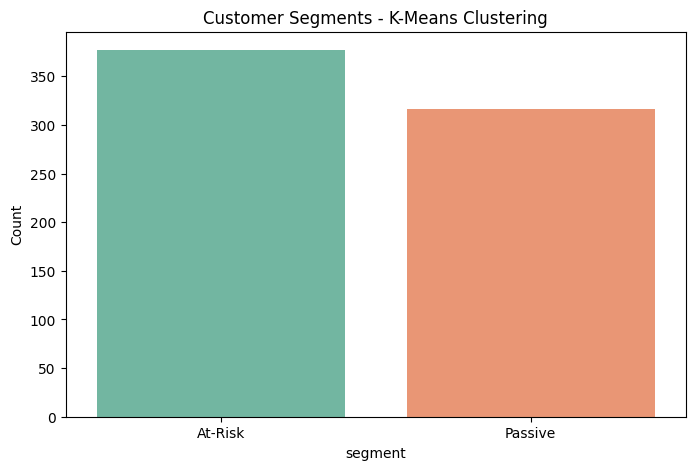

segment
At-Risk    377
Passive    316
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select features for clustering
features = df[['age', 'balance', 'credit_score', 'estimated_salary', 'tenure']]

# Step 2: Scale the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Find optimal clusters (Elbow Method)
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 8), inertia, marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Step 4: Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)

# Step 5: Label clusters
cluster_summary = df.groupby('cluster').agg(
    total_customers=('customer_id', 'count'),
    avg_balance=('balance', 'mean'),
    avg_age=('age', 'mean'),
    churn_rate=('churn', 'mean')
).round(2)

print(cluster_summary)

# Step 6: Name the clusters based on summary
df['segment'] = df['cluster'].map({
    df.groupby('cluster')['balance'].mean().idxmax(): 'VIP',
    df.groupby('cluster')['churn'].mean().idxmax(): 'At-Risk',
    df.groupby('cluster')['balance'].mean().idxmin(): 'Passive'
})

# Step 7: Visualize
plt.figure(figsize=(8,5))
sns.countplot(x='segment', data=df, palette='Set2')
plt.title("Customer Segments - K-Means Clustering")
plt.ylabel("Count")
plt.show()

print(df['segment'].value_counts())

segment
At-Risk    377
Passive    316
VIP        307
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_17760\257693471.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segment', data=df, palette='Set2')


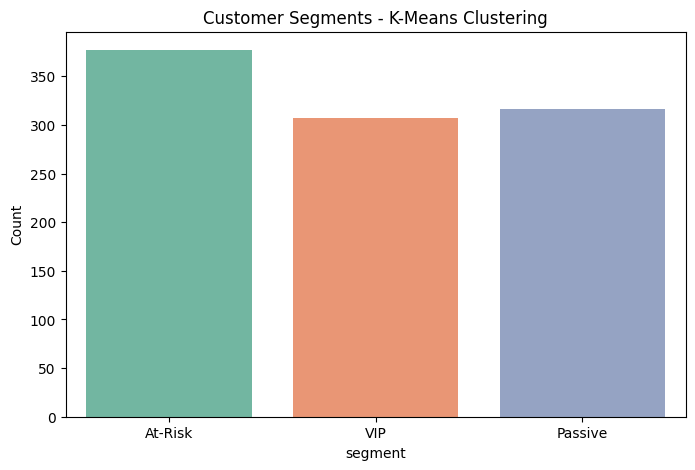

In [10]:
# Step 6: Name the clusters correctly
df['segment'] = df['cluster'].map({
    2: 'At-Risk',   # highest churn rate (0.23)
    1: 'VIP',       # highest balance (73,212)
    0: 'Passive'    # lowest balance (62,243)
})

# Verify
print(df['segment'].value_counts())

# Step 7: Visualize
plt.figure(figsize=(8,5))
sns.countplot(x='segment', data=df, palette='Set2')
plt.title("Customer Segments - K-Means Clustering")
plt.ylabel("Count")
plt.show()